# Análisis exploratorio distritos y selección del caso de estudio



Para la selección del distrito, se realiza un análisis exploratorio para el que se emplean cuatro meses representativos del año 2025: febrero, mayo, octubre y noviembre. Esta elección responde a la necesidad de capturar patrones de movilidad propios de días laborales, descartando aquellos periodos en los que las vacaciones, el turismo o los festivos modifican la demanda de tráfico y afecta a la carga viaria de desplazamientos al trabajo. 

## Configuración

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import zipfile
import gc
from pathlib import Path
import matplotlib.patches as mpatches
from pathlib import Path
import calendar

In [13]:
BASE_DIR = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\dataset')

RUTAS_MESES_EXPLORATORIOS = [
    {"historico": BASE_DIR / "historico" / "022025.zip", "ubicacion": BASE_DIR / "ptos_medida" / "202502.csv"},
    {"historico": BASE_DIR / "historico" / "052025.zip", "ubicacion": BASE_DIR / "ptos_medida" / "202505.csv"},
    {"historico": BASE_DIR / "historico" / "102025.zip", "ubicacion": BASE_DIR / "ptos_medida" / "202510.csv"},
    {"historico": BASE_DIR / "historico" / "112025.zip", "ubicacion": BASE_DIR / "ptos_medida" / "202511.csv"},]

SEPARADOR = ';'
FORMATO_FECHA = '%Y-%m-%d %H:%M:%S'

CARPETA_SALIDA = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\resultados\distritos')
CARPETA_SALIDA.mkdir(parents=True,exist_ok=True)

DISTRITOS_SELECCIONADOS = {'Retiro':3,'Salamanca':4,'Chamartin':5,'Tetuan':6,'Chamberi':7}
CODIGOS_DISTRITOS = list(DISTRITOS_SELECCIONADOS.values())

# Franja de hora punta de entrada al trabajo
HORAS_PUNTA = (7, 8, 9)

In [14]:
# PRUEBA EXPLORATORIA
primer_mes_historico = RUTAS_MESES_EXPLORATORIOS[0]["historico"]
primer_mes_ptosmedida = RUTAS_MESES_EXPLORATORIOS[0]["ubicacion"]
ptos_medida = pd.read_csv(primer_mes_ptosmedida, sep=SEPARADOR, encoding='latin-1')
historico = pd.read_csv(primer_mes_historico, sep=SEPARADOR, encoding='latin-1',compression='zip')
print(f'Columnas del dataset histórico: {historico.columns.tolist()}')
print(f'Columnas del dataset ptos_medida: {ptos_medida.columns.tolist()}')
print(historico.columns.tolist())
print(f'Categorías de tipo_elem: {ptos_medida["tipo_elem"].unique()}')
print(f'Categorías de distrito: {ptos_medida["distrito"].unique()}')
print(historico.info())
print(historico["fecha"])
print(historico["fecha"].isna().sum())
historico["fecha"] = pd.to_datetime(historico["fecha"], format=FORMATO_FECHA, errors="coerce")
print(historico["fecha"].isna().sum())

Columnas del dataset histórico: ['id', 'fecha', 'tipo_elem', 'intensidad', 'ocupacion', 'carga', 'vmed', 'error', 'periodo_integracion']
Columnas del dataset ptos_medida: ['tipo_elem', 'distrito', 'id', 'cod_cent', 'nombre', 'utm_x', 'utm_y', 'longitud', 'latitud']
['id', 'fecha', 'tipo_elem', 'intensidad', 'ocupacion', 'carga', 'vmed', 'error', 'periodo_integracion']
Categorías de tipo_elem: <ArrowStringArray>
['URB', 'M30', 'other']
Length: 3, dtype: str
Categorías de distrito: [ 4. 15. 16. 21. 20. 14. 13.  7.  8. 18. 19.  3.  2.  1. 12.  9.  6. nan
  5. 11. 10. 17.]
<class 'pandas.DataFrame'>
RangeIndex: 12056165 entries, 0 to 12056164
Data columns (total 9 columns):
 #   Column               Dtype  
---  ------               -----  
 0   id                   int64  
 1   fecha                str    
 2   tipo_elem            str    
 3   intensidad           int64  
 4   ocupacion            int64  
 5   carga                int64  
 6   vmed                 float64
 7   error     

## Lectura histórico y puntos de medida

Ahora vamos a cargar para cada uno de los cuatro meses el dataset de puntos de medida que contiene la ubicación de los sensores de cada mes, y el histórico de tráfico el cual vamos a leer en bloques.
Adicionalmente, como nos centramos en la simulación urbana, filtramos para quedarnos con los registros asociados (tipo_elem = URB).

Una vez ya hayamos leído la información correspondiente se agregan por distrito, tipo de dia y hora, acumulando todos los meses.

In [15]:
COLUMNAS = ["id", "fecha", "tipo_elem", "carga"]
TAM_BLOQUE = 2_000_000
patrones_distritos = []

for i, mes in enumerate(RUTAS_MESES_EXPLORATORIOS, start=1):
    print(f"Mes: {i}")
    ubicacion = pd.read_csv(mes["ubicacion"], sep=SEPARADOR,encoding='latin-1', usecols=["id", "distrito", "tipo_elem"])
    ubicacion["distrito"] = pd.to_numeric(ubicacion["distrito"], errors="coerce")
    ubicacion = ubicacion.dropna(subset=["distrito"])
    ubicacion["distrito"] = ubicacion["distrito"].astype(int)
    
    # Seleccionamos de los datos urbanos
    es_urbano = ubicacion[ubicacion['tipo_elem']=='URB']
    ubicacion = es_urbano[es_urbano["distrito"].isin(CODIGOS_DISTRITOS)]
    
    mapeo_sensores_distrito = ubicacion.set_index("id")["distrito"].to_dict()
    for nombre, codigo in DISTRITOS_SELECCIONADOS.items():
      n = sum(1 for j in mapeo_sensores_distrito.values() if j == codigo)
      print(f"{nombre} (distrito {codigo}): {n} sensores")
    
    lectura = pd.read_csv(mes["historico"],sep=SEPARADOR,usecols=COLUMNAS,chunksize=TAM_BLOQUE,encoding='latin-1',compression='zip')

    for bloque in lectura:
        bloque = bloque[bloque["id"].isin(mapeo_sensores_distrito)].copy()
        if bloque.empty:
            continue
        bloque["carga"] = pd.to_numeric(bloque["carga"], errors="coerce")
        bloque = bloque[bloque["carga"] >= 0]  # descarta valores negativos
        bloque["fecha"] = pd.to_datetime(bloque["fecha"], format=FORMATO_FECHA, errors="coerce")
        bloque["distrito"] = bloque["id"].map(mapeo_sensores_distrito)
        bloque["hora"] = bloque["fecha"].dt.hour
        bloque["dia_semana"] = bloque["fecha"].dt.dayofweek  # 0=lunes ... 6=domingo
        bloque["es_laborable"] = bloque["dia_semana"] < 5
        info = (bloque.groupby(["distrito", "es_laborable", "hora"])["carga"].agg(carga="sum",mediciones="count").reset_index())
        patrones_distritos.append(info)

df = pd.concat(patrones_distritos, ignore_index=True)
df = df.groupby(["distrito", "es_laborable", "hora"], as_index=False)[["carga", "mediciones"]].sum()
df["carga_media"] = df["carga"] / df["mediciones"]

Mes: 1
Retiro (distrito 3): 139 sensores
Salamanca (distrito 4): 196 sensores
Chamartin (distrito 5): 316 sensores
Tetuan (distrito 6): 241 sensores
Chamberi (distrito 7): 141 sensores
Mes: 2
Retiro (distrito 3): 139 sensores
Salamanca (distrito 4): 196 sensores
Chamartin (distrito 5): 316 sensores
Tetuan (distrito 6): 240 sensores
Chamberi (distrito 7): 141 sensores
Mes: 3
Retiro (distrito 3): 139 sensores
Salamanca (distrito 4): 195 sensores
Chamartin (distrito 5): 318 sensores
Tetuan (distrito 6): 240 sensores
Chamberi (distrito 7): 141 sensores
Mes: 4
Retiro (distrito 3): 139 sensores
Salamanca (distrito 4): 195 sensores
Chamartin (distrito 5): 318 sensores
Tetuan (distrito 6): 240 sensores
Chamberi (distrito 7): 141 sensores


Observamos que el número de sensores permanece bastante constante en los cuatro meses tratados pero si que vemos que en alguno de los meses hay pequeñas variaciones (e.g. Tetúan).


Comprobemos que la salida obtenida es coherente.


In [16]:
print(df.shape)
print(df['distrito'].unique())
print(df['hora'].unique())
df.head()

(240, 6)
[3 4 5 6 7]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


,distrito,es_laborable,hora,carga,mediciones,carga_media
0,3,False,0,273539,17318,15.795069
1,3,False,1,208183,17294,12.037874
2,3,False,2,156538,17218,9.091532
3,3,False,3,122378,17084,7.163311
4,3,False,4,102807,16955,6.063521


Como estamos agrupando por distrito, es_laborable y hora, y tenemos 5 distritos x 2 tipos para es_laborable x 24 horas = 240 filas, luego es coherente la salida obtenida.
Además, observamos que contiene registros para los 5 distritos que estamos explorando y las horas de 0 a 23h.

## Carga media y HML

A continuación se obtiene la carga media de cada hora agrupando los registros  por distrito, tipo de día y hora. Adicionalmente, se calcula la métrica de Huella de Movilidad Laboral (HML) ya que nos va a ayudar con la elecci

In [18]:
def carga_media_franja(codigo, laborable, horas=HORAS_PUNTA):
    datos = df[(df["distrito"] == codigo) & (df["es_laborable"] == laborable) &(df["hora"].isin(horas))]
    return np.average(datos["carga_media"], weights=datos["mediciones"])

ranking = pd.DataFrame(list(DISTRITOS_SELECCIONADOS.items()),columns=["nombre_distrito", "codigo_distrito"])
ranking["carga_media_hpunta_laborable"] = ranking["codigo_distrito"].apply(lambda c: carga_media_franja(c, True)).round(1)
ranking["carga_media_hpunta_nolaborable"]     = ranking["codigo_distrito"].apply(lambda c: carga_media_franja(c, False)).round(1)
ranking["HML"]    = (ranking["carga_media_hpunta_laborable"] - ranking["carga_media_hpunta_nolaborable"]).round(1)
ranking = ranking.sort_values("HML", ascending=False).reset_index(drop=True)

ranking.to_csv(CARPETA_SALIDA / "ranking_distritos.csv", index=False)
print("\nRanking por HML (carga media hora punta laborable - carga media hora punta no laborable):\n")
ranking


Ranking por HML (carga media hora punta laborable - carga media hora punta no laborable):



,nombre_distrito,codigo_distrito,carga_media_hpunta_laborable,carga_media_hpunta_nolaborable,HML
0,Chamberi,7,31.4,9.7,21.7
1,Salamanca,4,30.8,9.2,21.6
2,Retiro,3,30.4,10.1,20.3
3,Chamartin,5,25.9,7.0,18.9
4,Tetuan,6,20.9,6.4,14.5


Visualizamos los perfiles horarios de días laborables y no laborables

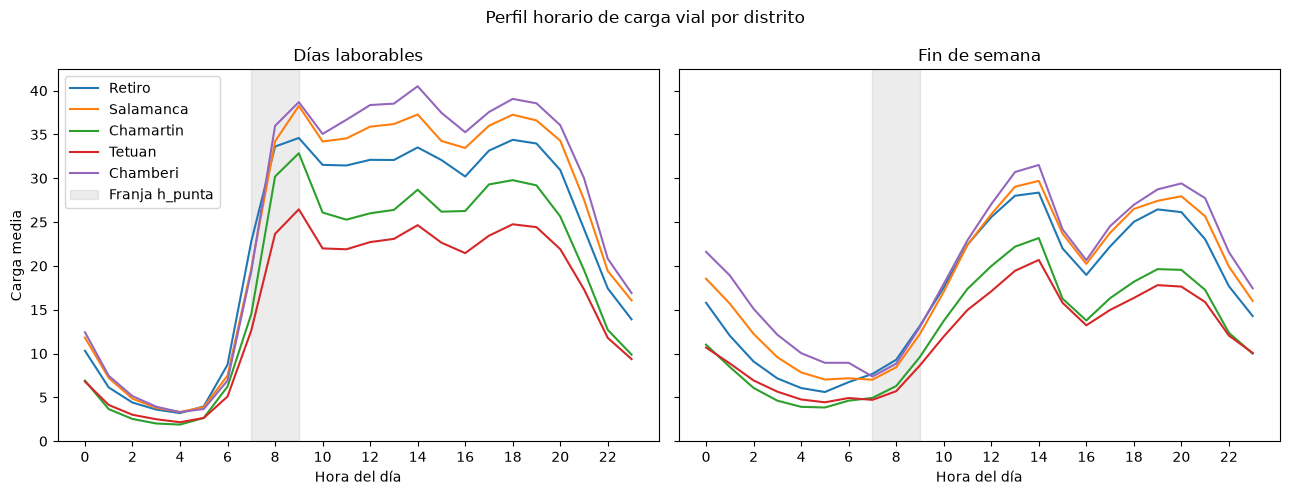

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for nombre, codigo in DISTRITOS_SELECCIONADOS.items():

    perfil_lab = df[(df["distrito"] == codigo) &(df["es_laborable"])].sort_values("hora")
    perfil_finde = df[(df["distrito"] == codigo) &(~df["es_laborable"])].sort_values("hora")

    axes[0].plot(perfil_lab["hora"],perfil_lab["carga_media"],label=nombre)
    axes[1].plot(perfil_finde["hora"],perfil_finde["carga_media"],label=nombre)


axes[0].set_title("Días laborables")
axes[1].set_title("Fin de semana")

for ax in axes:
    ax.axvspan(7, 9, alpha=0.15, color="grey", label="Franja h_punta")
    ax.set_xlabel("Hora del día")
    ax.set_xticks(range(0, 24, 2))


axes[0].set_ylabel("Carga media")
axes[0].legend()

fig.suptitle("Perfil horario de carga vial por distrito")
fig.tight_layout()

fig.savefig(CARPETA_SALIDA / "perfil_horario_por_distrito.png",dpi=150)

plt.show()

## Conclusión

Tras analizar los perfiles horarios de carga media por distrito, se observa que Chamberí (distrito 7) presenta los valores de carga media más elevados durante prácticamente todo el periodo diario.


Además, este distrito muestra la mayor diferencia entre los niveles de carga registrados en días laborables y fines de semana durante la franja de hora punta, lo que indica un patrón de movilidad  condicionado por la actividad laboral.

Por estos motivos, **Chamberí** se identifica como el distrito con un comportamiento de movilidad más significativo dentro de los distritos seleccionados y pasa a ser nuestra zona de estudio.